In [1]:
import ast
import pandas as pd
import numpy as np
import seaborn as sbs
import matplotlib.pyplot as plt
from datasets import load_dataset

datasets = load_dataset('lukebarousse/data_jobs')
df = datasets['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_Ind = df[df['job_country'] == 'India']

In [3]:
df_skills = df_Ind.explode('job_skills')
df_skills[['job_title', 'job_skills']]

,job_title,job_skills
16,Big Data Engineer,powershell
16,Big Data Engineer,python
16,Big Data Engineer,sql
16,Big Data Engineer,mysql
16,Big Data Engineer,sql server
...,...,...
785716,Application Support Analyst,c#
785716,Application Support Analyst,sql
785718,Senior Performance QA Analyst,None
785740,AWS System Analyst,aws


In [4]:
df_skill_count = df_skills.groupby(['job_title_short', 'job_skills']).size()
df_skill_count = df_skill_count.reset_index(name='skill_count')
df_skill_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skill_count

,job_title_short,job_skills,skill_count
637,Data Engineer,sql,12993
603,Data Engineer,python,11568
807,Data Scientist,python,9248
632,Data Engineer,spark,7157
480,Data Engineer,aws,6993
...,...,...,...
1472,Senior Data Scientist,svn,1
998,Machine Learning Engineer,svn,1
138,Business Analyst,twilio,1
835,Data Scientist,solidity,1


In [37]:
df_titles = df_skill_count['job_title_short'].unique().tolist()
df_titles = sorted(df_titles[:3])
df_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

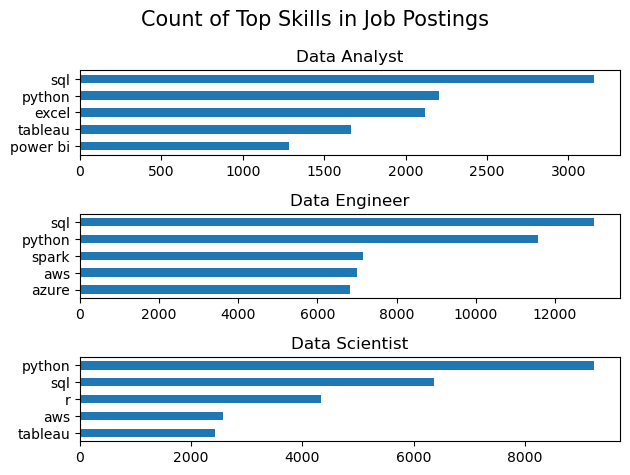

In [38]:
fig, ax = plt.subplots(len(df_titles),1)

for i,job_title in enumerate(df_titles):
    df_plot = df_skill_count[df_skill_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title = job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Count of Top Skills in Job Postings', fontsize = 15)
fig.tight_layout()
plt.show()

In [33]:
df_total_count = df_Ind['job_title_short'].value_counts().reset_index(name='job_count')

In [34]:
df_skill_perc = pd.merge(df_total_count, df_skill_count, on='job_title_short', how='left')
df_skill_perc['skill_perc'] = 100*df_skill_perc['skill_count']/ df_skill_perc['job_count']
df_skill_perc

,job_title_short,job_count,job_skills,skill_count,skill_perc
0,Data Engineer,19062,sql,12993,68.161788
1,Data Engineer,19062,python,11568,60.686182
2,Data Engineer,19062,spark,7157,37.545903
3,Data Engineer,19062,aws,6993,36.685552
4,Data Engineer,19062,azure,6819,35.772742
...,...,...,...,...,...
1684,Cloud Engineer,351,cognos,1,0.284900
1685,Cloud Engineer,351,centos,1,0.284900
1686,Cloud Engineer,351,assembly,1,0.284900
1687,Cloud Engineer,351,asp.net,1,0.284900


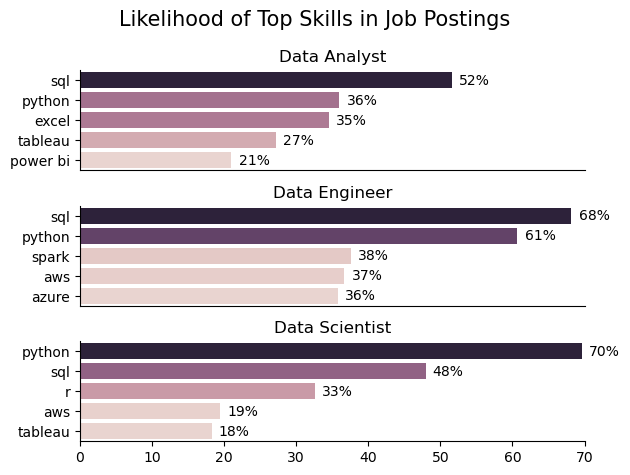

In [39]:
fig, ax = plt.subplots(len(df_titles),1)

for i,job_title in enumerate(df_titles):
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head(5)
    #df_plot.plot(kind='barh', x='job_skills', y='skill_perc', ax=ax[i], title = job_title)
    sbs.barplot(data=df_plot, x='skill_perc', y='job_skills', ax=ax[i], hue='skill_perc')
    ax[i].set_title(job_title)
    ax[i].invert_xaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 70)
    sbs.despine()

    for n,v in enumerate(df_plot['skill_perc']):
        ax[i].text(v+1, n, f'{v:.0f}%', va='center')

    if i != len(df_titles)-1:
        ax[i].set_xticks([])    

fig.suptitle('Likelihood of Top Skills in Job Postings', fontsize = 15)
fig.tight_layout()
plt.show()